In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv(os.path.join("gcs-data", "GBD_paper", "sbod_data_cleaned.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           161028 non-null  int64
 1   Cause          161028 non-null  str  
 2   Location       161028 non-null  str  
 3   Age            161028 non-null  str  
 4   Sex            161028 non-null  str  
 5   RAG            161028 non-null  str  
 6   Measure        161028 non-null  str  
 7   Value          161028 non-null  str  
 8   Small numbers  161028 non-null  str  
dtypes: int64(1), str(8)
memory usage: 11.1 MB


In [39]:
df["Location"].unique()

<StringArray>
[                     'Scotland',                 'East Scotland',
                 'West Scotland',                'North Scotland',
        'NHS Ayrshire and Arran',                   'NHS Borders',
     'NHS Dumfries and Galloway',              'NHS Forth Valley',
                  'NHS Grampian',                  'NHS Highland',
                   'NHS Lothian',                    'NHS Orkney',
                  'NHS Shetland',             'NHS Western Isles',
                      'NHS Fife',                   'NHS Tayside',
 'NHS Greater Glasgow and Clyde',               'NHS Lanarkshire']
Length: 18, dtype: str

In [43]:
folder = "data"
f_corr, m_corr = {}, {}

for loc in df["Location"].unique():
    file = f"{loc.replace(' ', '_').lower()}_analysis.xlsx"
    if not os.path.exists(os.path.join(folder, file)):
        continue
    cols = [f"{loc}_CAGR_2014", f"{loc}_CAGR_2017"] + [f"{loc}_tsq2_{norm_mode}" for norm_mode in ["mean", "median", "interval", "base"]] + [f"{loc}_tsq3_{norm_mode}" for norm_mode in ["mean", "median", "interval", "base"]]
    if file.endswith(".xlsx"):
        f_df = pd.read_excel(os.path.join(folder, file), sheet_name="Female")
        m_df = pd.read_excel(os.path.join(folder, file), sheet_name="Male")
        f_corr[loc] = {
                        "Pearson": f_df[cols].corr(method="pearson").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist(),
                        "Spearman": f_df[cols].corr(method="spearman").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist(),
                        "Kendall": f_df[cols].corr(method="kendall").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist()
                    }
        m_corr[loc] = {
                        "Pearson": m_df[cols].corr(method="pearson").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist(),
                        "Spearman": m_df[cols].corr(method="spearman").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist(),
                        "Kendall": m_df[cols].corr(method="kendall").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist()
                    }
len(f_corr), len(m_corr)

(17, 17)

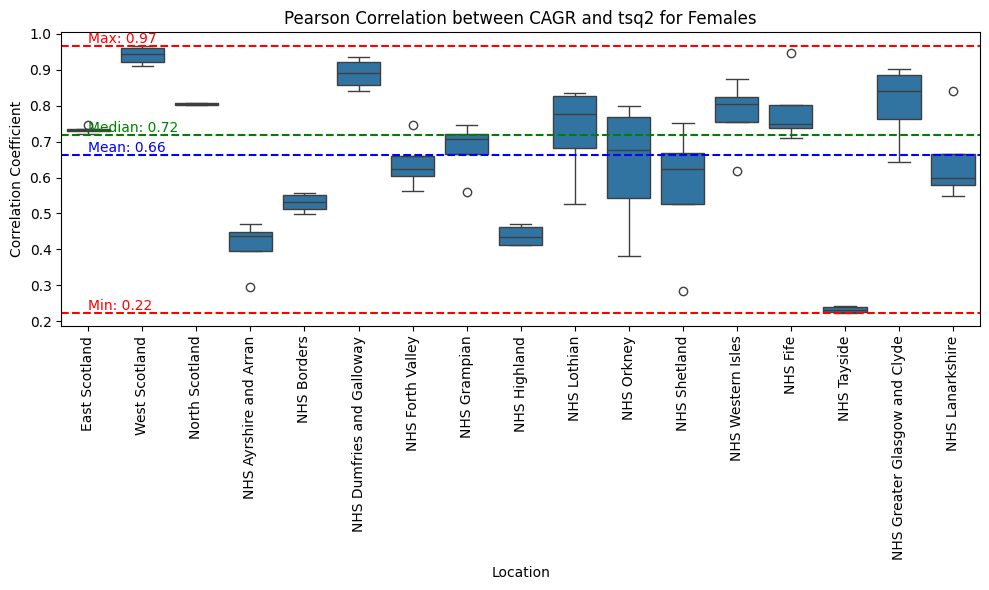

In [48]:
corr_type = "Pearson"
data = [{"loc": loc, "corr": f_corr[loc][corr_type]} for loc in f_corr]

all_corr = []

for d in data:
	all_corr.extend(d["corr"])

min_val = min([min(d["corr"]) for d in data])
max_val = max([max(d["corr"]) for d in data])
mean_val = sum([sum(d["corr"]) for d in data]) / sum([len(d["corr"]) for d in data])
median_val = np.median(all_corr)

plot_data = pd.DataFrame(
	[{"loc": d["loc"], "corr": v} for d in data for v in d["corr"]]
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x="loc", y="corr")
plt.axhline(min_val, color="red", linestyle="--")
plt.axhline(max_val, color="red", linestyle="--")
plt.axhline(mean_val, color="blue", linestyle="--")
plt.axhline(median_val, color="green", linestyle="--")
# Annotate the min and max values
plt.text(0, min_val, f"Min: {min_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, max_val, f"Max: {max_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, mean_val, f"Mean: {mean_val:.2f}", color="blue", va="bottom", ha="left")
plt.text(0, median_val, f"Median: {median_val:.2f}", color="green", va="bottom", ha="left")

plt.xticks(rotation=90)
plt.title(f"{corr_type} Correlation between CAGR and tsq2 for Females")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Location")
plt.tight_layout()
plt.show()

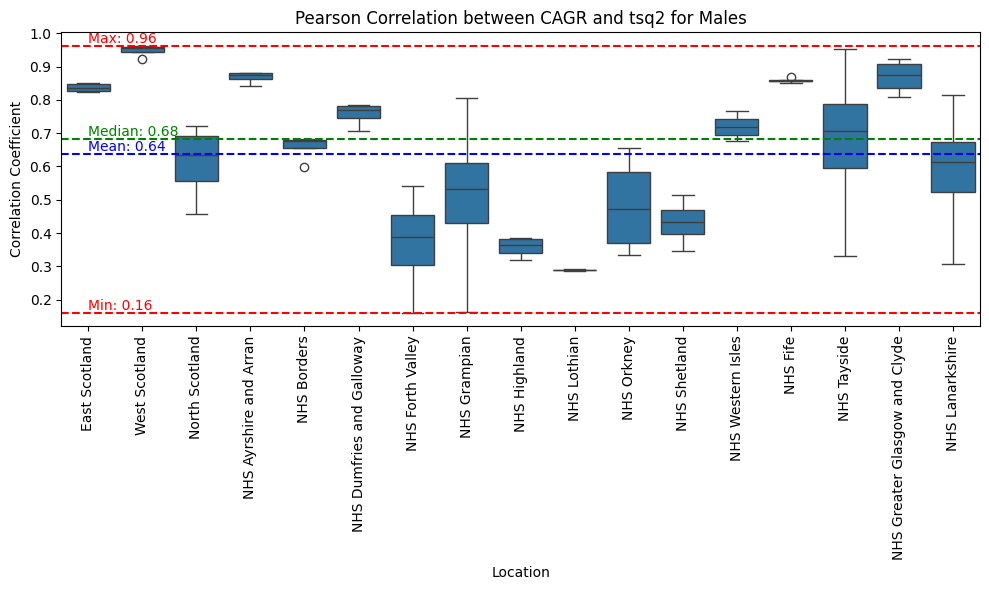

In [49]:
corr_type = "Pearson"
data = [{"loc": loc, "corr": m_corr[loc][corr_type]} for loc in m_corr]

all_corr = []

for d in data:
	all_corr.extend(d["corr"])

min_val = min([min(d["corr"]) for d in data])
max_val = max([max(d["corr"]) for d in data])
mean_val = sum([sum(d["corr"]) for d in data]) / sum([len(d["corr"]) for d in data])
median_val = np.median(all_corr)

plot_data = pd.DataFrame(
	[{"loc": d["loc"], "corr": v} for d in data for v in d["corr"]]
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x="loc", y="corr")
plt.axhline(min_val, color="red", linestyle="--")
plt.axhline(max_val, color="red", linestyle="--")
plt.axhline(mean_val, color="blue", linestyle="--")
plt.axhline(median_val, color="green", linestyle="--")
# Annotate the min and max values
plt.text(0, min_val, f"Min: {min_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, max_val, f"Max: {max_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, mean_val, f"Mean: {mean_val:.2f}", color="blue", va="bottom", ha="left")
plt.text(0, median_val, f"Median: {median_val:.2f}", color="green", va="bottom", ha="left")

plt.xticks(rotation=90)
plt.title(f"{corr_type} Correlation between CAGR and tsq2 for Males")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Location")
plt.tight_layout()
plt.show()

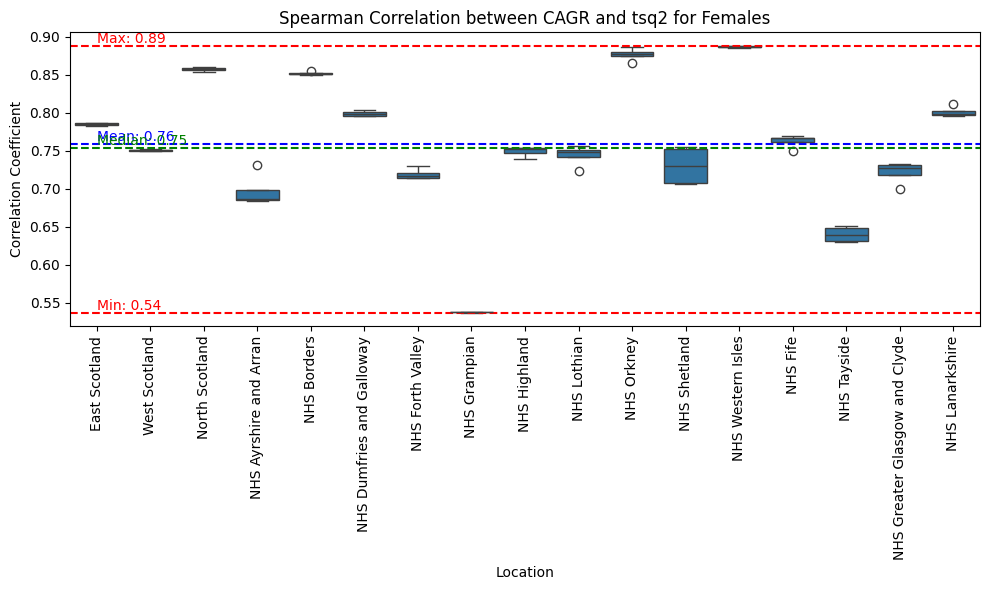

In [50]:
corr_type = "Spearman"
data = [{"loc": loc, "corr": f_corr[loc][corr_type]} for loc in f_corr]

all_corr = []

for d in data:
	all_corr.extend(d["corr"])

min_val = min([min(d["corr"]) for d in data])
max_val = max([max(d["corr"]) for d in data])
mean_val = sum([sum(d["corr"]) for d in data]) / sum([len(d["corr"]) for d in data])
median_val = np.median(all_corr)

plot_data = pd.DataFrame(
	[{"loc": d["loc"], "corr": v} for d in data for v in d["corr"]]
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x="loc", y="corr")
plt.axhline(min_val, color="red", linestyle="--")
plt.axhline(max_val, color="red", linestyle="--")
plt.axhline(mean_val, color="blue", linestyle="--")
plt.axhline(median_val, color="green", linestyle="--")
# Annotate the min and max values
plt.text(0, min_val, f"Min: {min_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, max_val, f"Max: {max_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, mean_val, f"Mean: {mean_val:.2f}", color="blue", va="bottom", ha="left")
plt.text(0, median_val, f"Median: {median_val:.2f}", color="green", va="bottom", ha="left")

plt.xticks(rotation=90)
plt.title(f"{corr_type} Correlation between CAGR and tsq2 for Females")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Location")
plt.tight_layout()
plt.show()

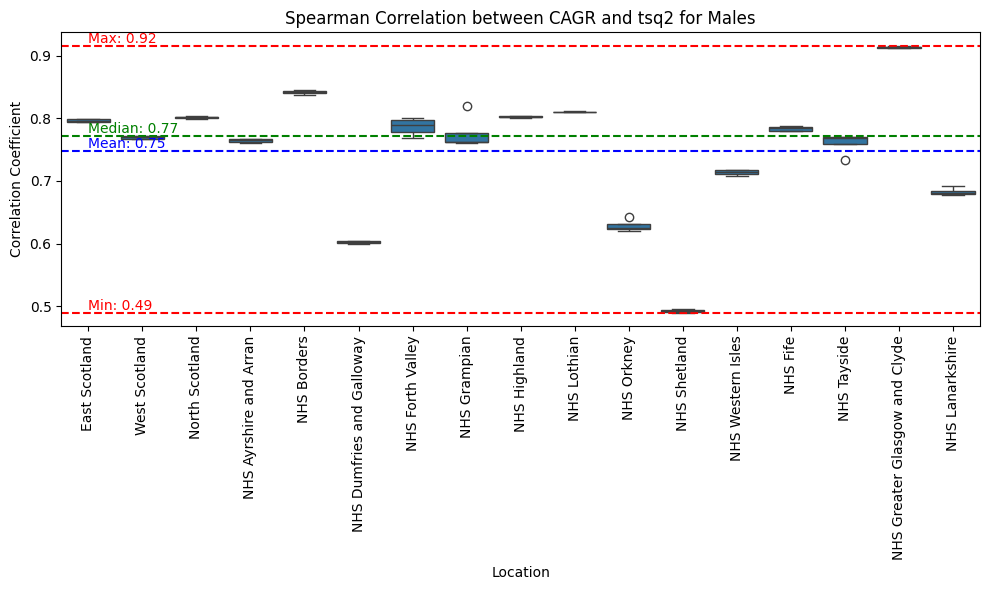

In [51]:
corr_type = "Spearman"
data = [{"loc": loc, "corr": m_corr[loc][corr_type]} for loc in m_corr]

all_corr = []

for d in data:
	all_corr.extend(d["corr"])

min_val = min([min(d["corr"]) for d in data])
max_val = max([max(d["corr"]) for d in data])
mean_val = sum([sum(d["corr"]) for d in data]) / sum([len(d["corr"]) for d in data])
median_val = np.median(all_corr)

plot_data = pd.DataFrame(
	[{"loc": d["loc"], "corr": v} for d in data for v in d["corr"]]
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x="loc", y="corr")
plt.axhline(min_val, color="red", linestyle="--")
plt.axhline(max_val, color="red", linestyle="--")
plt.axhline(mean_val, color="blue", linestyle="--")
plt.axhline(median_val, color="green", linestyle="--")
# Annotate the min and max values
plt.text(0, min_val, f"Min: {min_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, max_val, f"Max: {max_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, mean_val, f"Mean: {mean_val:.2f}", color="blue", va="bottom", ha="left")
plt.text(0, median_val, f"Median: {median_val:.2f}", color="green", va="bottom", ha="left")

plt.xticks(rotation=90)
plt.title(f"{corr_type} Correlation between CAGR and tsq2 for Males")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Location")
plt.tight_layout()
plt.show()

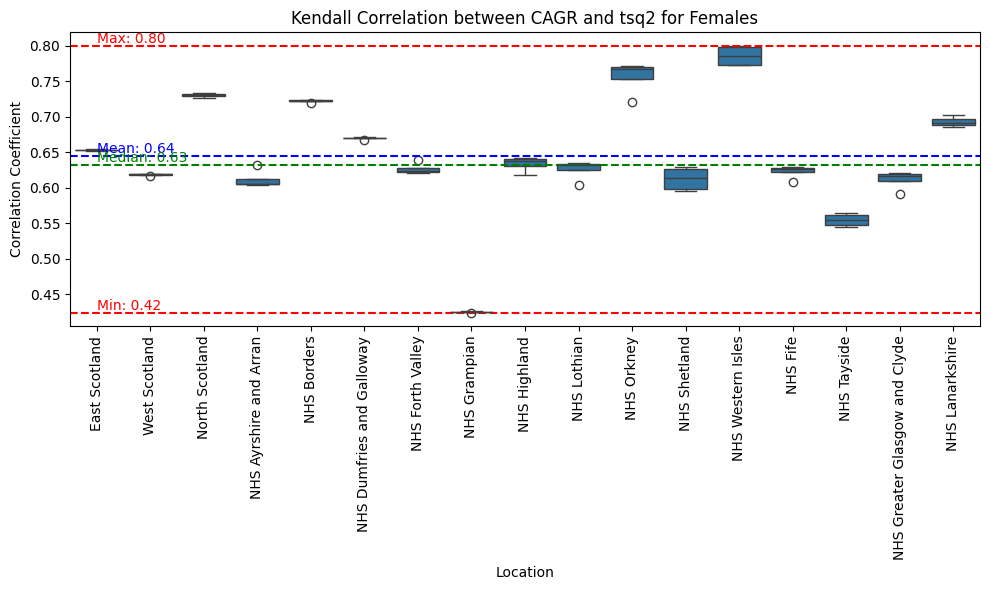

In [52]:
corr_type = "Kendall"
data = [{"loc": loc, "corr": f_corr[loc][corr_type]} for loc in f_corr]

all_corr = []

for d in data:
	all_corr.extend(d["corr"])

min_val = min([min(d["corr"]) for d in data])
max_val = max([max(d["corr"]) for d in data])
mean_val = sum([sum(d["corr"]) for d in data]) / sum([len(d["corr"]) for d in data])
median_val = np.median(all_corr)

plot_data = pd.DataFrame(
	[{"loc": d["loc"], "corr": v} for d in data for v in d["corr"]]
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x="loc", y="corr")
plt.axhline(min_val, color="red", linestyle="--")
plt.axhline(max_val, color="red", linestyle="--")
plt.axhline(mean_val, color="blue", linestyle="--")
plt.axhline(median_val, color="green", linestyle="--")
# Annotate the min and max values
plt.text(0, min_val, f"Min: {min_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, max_val, f"Max: {max_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, mean_val, f"Mean: {mean_val:.2f}", color="blue", va="bottom", ha="left")
plt.text(0, median_val, f"Median: {median_val:.2f}", color="green", va="bottom", ha="left")

plt.xticks(rotation=90)
plt.title(f"{corr_type} Correlation between CAGR and tsq2 for Females")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Location")
plt.tight_layout()
plt.show()

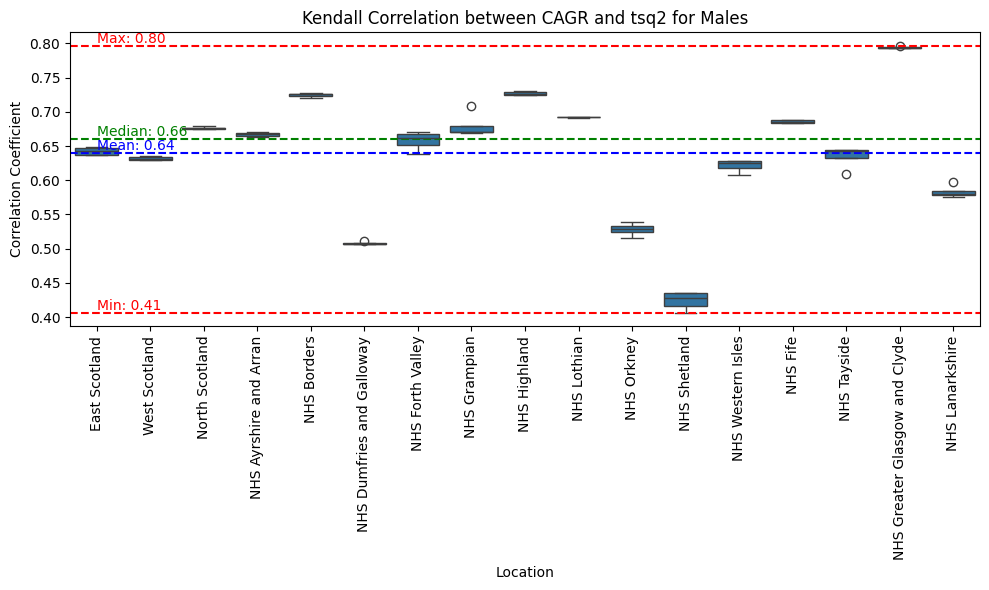

In [53]:
corr_type = "Kendall"
data = [{"loc": loc, "corr": m_corr[loc][corr_type]} for loc in m_corr]

all_corr = []

for d in data:
	all_corr.extend(d["corr"])

min_val = min([min(d["corr"]) for d in data])
max_val = max([max(d["corr"]) for d in data])
mean_val = sum([sum(d["corr"]) for d in data]) / sum([len(d["corr"]) for d in data])
median_val = np.median(all_corr)

plot_data = pd.DataFrame(
	[{"loc": d["loc"], "corr": v} for d in data for v in d["corr"]]
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x="loc", y="corr")
plt.axhline(min_val, color="red", linestyle="--")
plt.axhline(max_val, color="red", linestyle="--")
plt.axhline(mean_val, color="blue", linestyle="--")
plt.axhline(median_val, color="green", linestyle="--")
# Annotate the min and max values
plt.text(0, min_val, f"Min: {min_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, max_val, f"Max: {max_val:.2f}", color="red", va="bottom", ha="left")
plt.text(0, mean_val, f"Mean: {mean_val:.2f}", color="blue", va="bottom", ha="left")
plt.text(0, median_val, f"Median: {median_val:.2f}", color="green", va="bottom", ha="left")

plt.xticks(rotation=90)
plt.title(f"{corr_type} Correlation between CAGR and tsq2 for Males")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Location")
plt.tight_layout()
plt.show()